In [1]:
"""
Solution to STA-Mid Term

Author: Jingyi Lu
Date:   23.06.2022
Ver:    1.0

"""

# standard packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

# additional packages
from scipy import signal
import scipy.io

In [5]:
def read_in_data(in_file):
    """ Read in the data """  

    mat = scipy.io.loadmat(in_file)
   
    # convert it into array-format
    new_val = mat.items()
    elemen = list(new_val)
    con_arr = np.array(elemen)

    # Abstract array values
    data = con_arr[-1] 
    data = data[-1] 
    
    return data

In [63]:
def find_hbr(data):
    """ functions """
    # Calculates the first derivative
    first_derivative = signal.savgol_filter(data, window_length=71, polyorder=3, deriv=1, delta=1 / rate, axis=0)
    print(f'the first_derivative is:')
    print(first_derivative)
    #fig1 = plt.figure
    #plt.plot(first_derivative,'b')
    
    # finds the times when the signal rises from below to abovethat threshold.
    threshold = 100
    large = (first_derivative > threshold)*1
    changes = np.diff(large)
    go_up = np.where(changes == 1)[0]
    #print(f'the times when the signal rises from below to above that threshold:')
    #print(go_up)
    
    # Calculates the Heart-Beat-Rate (HBR)
    
    # standard deviation
    sd = np.sqrt(np.std(first_derivative, ddof=1, axis=0))
    print(f'the standard deviation is:')
    print(sd)
    
    constant = 4.56
    return constant


the read-in data is:
[[-0.714417]
 [-0.55069 ]
 [-0.458832]
 ...
 [-0.974731]
 [-1.05545 ]
 [-1.053925]]


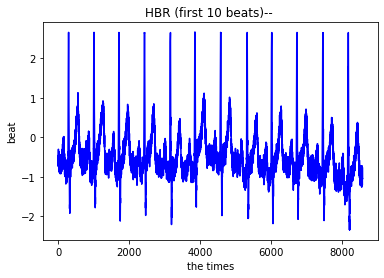

Image saved to HRV.png
the first_derivative is:
[[ 3.73179501]
 [ 3.13579982]
 [ 2.56078889]
 ...
 [-2.38669523]
 [-2.69617047]
 [-3.0182073 ]]
the standard deviation is:
[5.70025956]
HBR = 4.56


<Figure size 432x288 with 0 Axes>

In [65]:
if __name__ == '__main__':
    
    # Set the parameters
    rate = 1000
    
    # Get the data
    in_file = 'ecg_hfn.mat'
    data = read_in_data(in_file)
    print(f'the read-in data is:')
    print(data)
    
    # Call the function
    #find_hbr(data)

    # Generate a figure with the ECG data
    fig1 = plt.figure
    plt.plot(data,'b')
    plt.title('HBR (first 10 beats)-- ')
    plt.ylabel('beat')  
    plt.xlabel('the times')    
    plt.show()

    # Save Figure
    out_file = 'HRV.png'
    plt.savefig(out_file, dpi=200)
    print('Image saved to {0}'.format(out_file))


    # Displays the value returned from ’find hbr’ on the command-line
    print('HBR = {0}'.format(find_hbr(data)))